<a href="https://colab.research.google.com/github/nm-razon/Pythone-Code/blob/main/PH_Sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

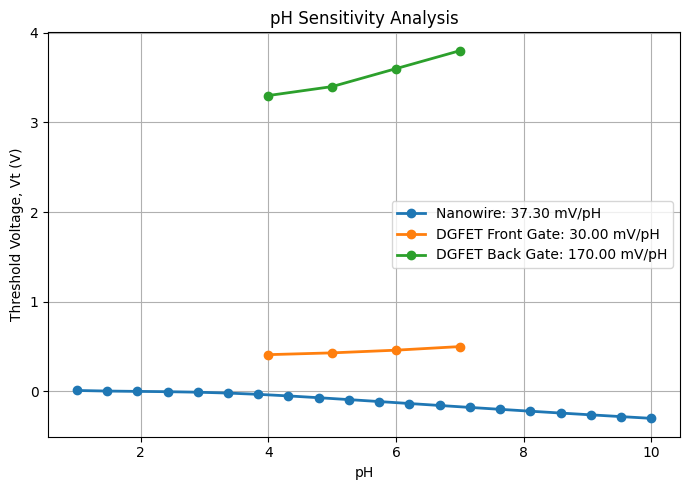

Sensitivity Results:
Nanowire: 37.30 mV/pH
DGFET Front Gate: 30.00 mV/pH
DGFET Back Gate: 170.00 mV/pH


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Nanowire": "Nanowire_sensitivity.txt",
    "DGFET Front Gate": "DGFET_frontgate_sensitivity.txt",
    "DGFET Back Gate": "DGFET_backgate_sensitivity.txt"
}

results = {}

plt.figure(figsize=(7,5))

for label, filename in files.items():
    data = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if "," in line and not line.lower().startswith("ph"):
                parts = line.split(",")

                try:
                    ph = float(parts[0])
                    vt = float(parts[1])
                    data.append([ph, vt])
                except:
                    pass

    df = pd.DataFrame(data, columns=["pH", "Vt"])

    # Linear fit: Vt = m*pH + b
    m, b = np.polyfit(df["pH"], df["Vt"], 1)

    sensitivity_mv_per_ph = abs(m) * 1000
    results[label] = sensitivity_mv_per_ph

    plt.plot(df["pH"], df["Vt"], "o-", linewidth=2,
             label=f"{label}: {sensitivity_mv_per_ph:.2f} mV/pH")

plt.xlabel("pH")
plt.ylabel("Threshold Voltage, Vt (V)")
plt.title("pH Sensitivity Analysis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=300)
plt.show()

print("Sensitivity Results:")
for label, sensitivity in results.items():
    print(f"{label}: {sensitivity:.2f} mV/pH")